In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/simple_placement_dataset.csv')

In [13]:
import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_dataset.csv',
 'placement_predict_50k Dataset (1).csv',
 'age_insurance.csv',
 'simple_placement_dataset.csv']

In [20]:
import os

print("Current folder:")
print(os.getcwd())

print("\nCSV files available:")
for file in os.listdir():
    if file.lower().endswith(".csv"):
        print(file)

Current folder:
/content

CSV files available:
simple_placement_dataset.csv
placement_predict_50k_Dataset_cleaned.csv


Accuracy: 0.998
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3422
           1       1.00      1.00      1.00      6578

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

Saved tree image.


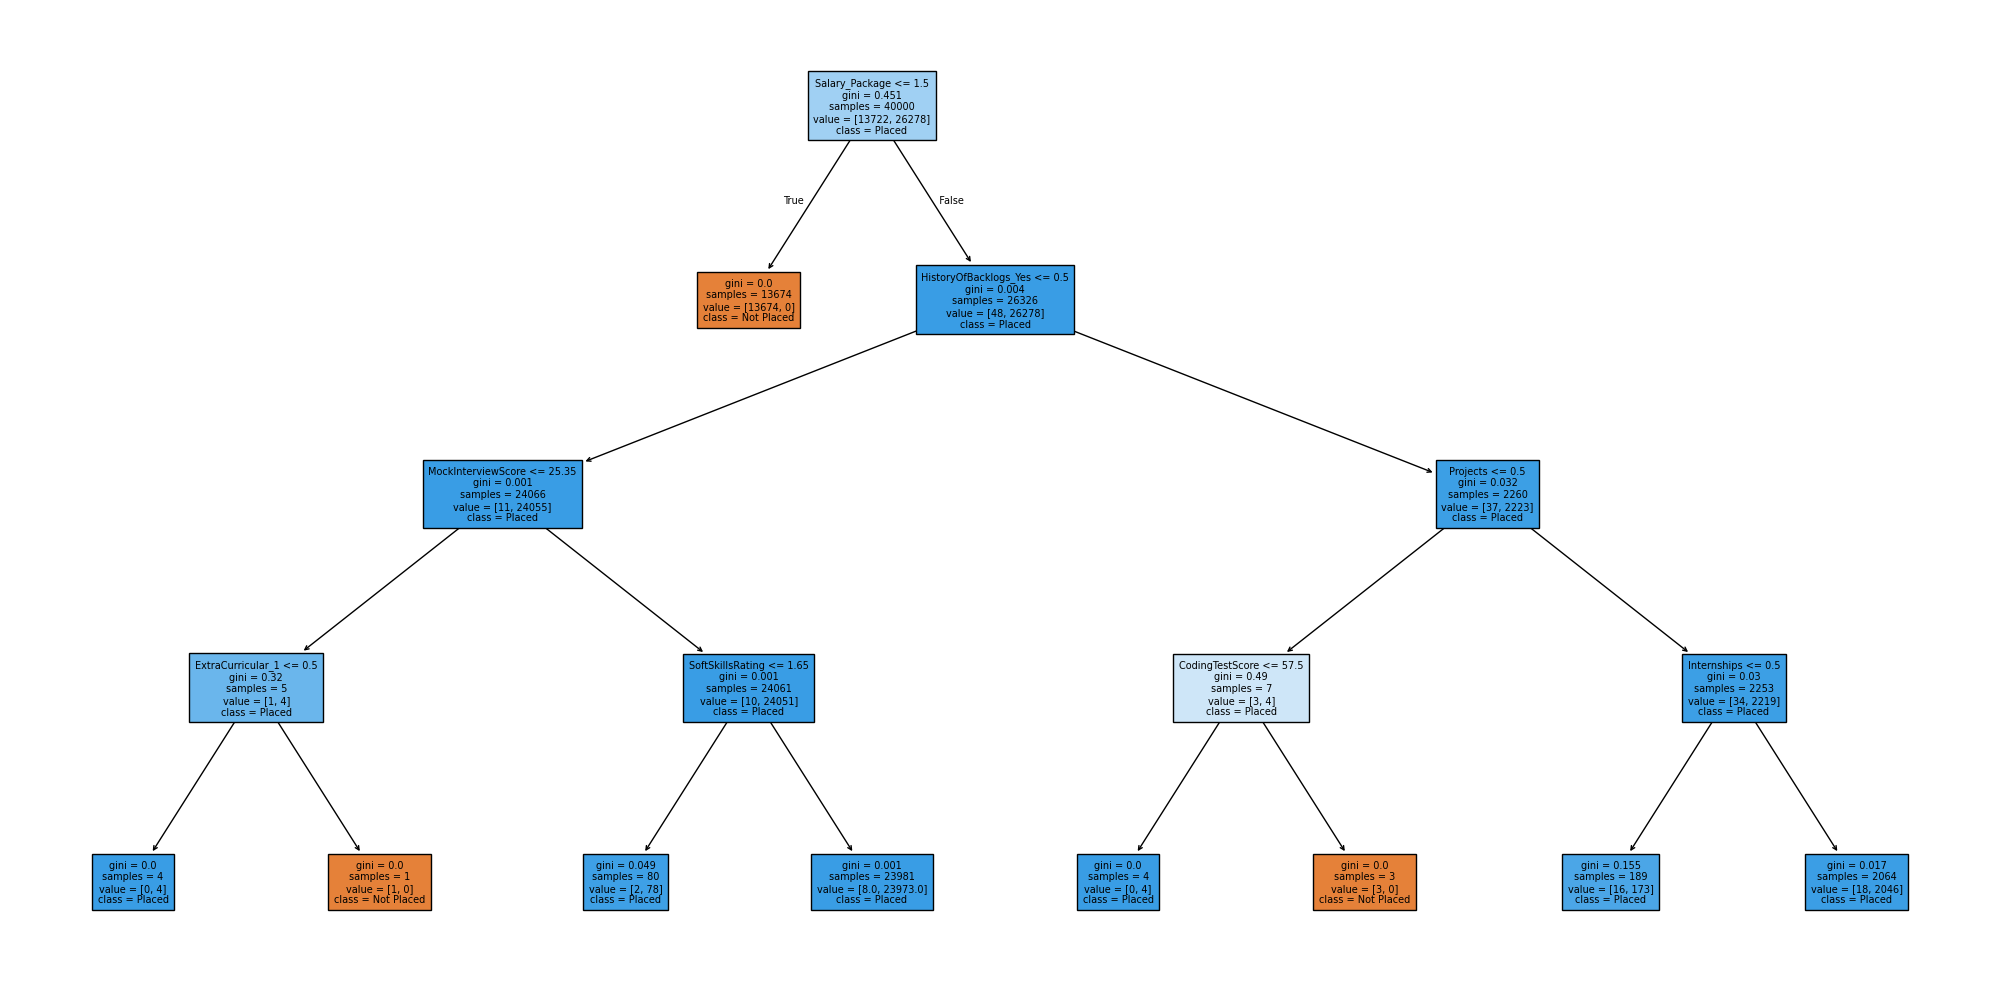

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

df = pd.read_csv('placement_predict_50k_Dataset_cleaned.csv')
df = df.drop(columns=['IsAnomaly'])

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

df_encoded = pd.get_dummies(df, columns=[
    'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation',
    'Hostel', 'HistoryOfBacklogs', 'ExtraCurricular', 'CGPA_Tier'
], drop_first=True)

X = df_encoded.drop(columns=['PlacementStatus'])
y = df_encoded['PlacementStatus']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=['Not Placed', 'Placed'], filled=True, fontsize=7)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150)
print("Saved tree image.")

In [22]:
print(df.info())
for col in df.select_dtypes(include='object').columns:
    print(f"\nUnique values in '{col}':")
    print(df[col].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           50000 non-null  int64  
 1   Gender              50000 non-null  object 
 2   City                50000 non-null  object 
 3   CollegeTier         50000 non-null  object 
 4   Stream              50000 non-null  object 
 5   Specialisation      50000 non-null  object 
 6   Hostel              50000 non-null  object 
 7   HistoryOfBacklogs   50000 non-null  object 
 8   SGPA_Sem1           50000 non-null  float64
 9   SGPA_Sem2           50000 non-null  float64
 10  SGPA_Sem3           50000 non-null  float64
 11  SGPA_Sem4           50000 non-null  float64
 12  SGPA_Sem5           50000 non-null  float64
 13  SGPA_Sem6           50000 non-null  float64
 14  SGPA_Sem7           50000 non-null  float64
 15  SGPA_Sem8           50000 non-null  float64
 16  CGPA